<a href="https://colab.research.google.com/github/SumaiyaZohaRODELA/CKD-NHANES-2021-2023-Staged-Kidney-Diseases_-Data-science/blob/main/CKD_NHANES_2021_2023_Staged_Kidney_Diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
alitaqishah_ckd_nhanes_2021_2023_staged_kidney_disease_path = kagglehub.dataset_download('alitaqishah/ckd-nhanes-2021-2023-staged-kidney-disease')

print('Data source import complete.')

100%|██████████| 372k/372k [00:00<00:00, 73.1MB/s]

Extracting files...
Data source import complete.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy as sp
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

#OSEMN Pipeline  (eita follow korbo for DA projects)

O - Obtaining our data

S - Scrubbing / Cleaning our data

E - Exploring / Visualizing our data will allow us to find patterns and trends

M - Modeling our data will give us our predictive power as a wizard

N - Interpreting our data

# Data Preprocessing

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/data_diabetes/CKD.csv')

In [8]:

#displaying the head of dataset
df.head()

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [9]:

#description of dataset
df.describe()

,participant_id,age,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,...,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_present
count,11933.000000,1.193300e+04,7794.000000,9.892000e+03,8471.000000,8754.000000,8499.000000,7517.000000,7517.000000,6326.000000,...,8154.000000,8153.000000,8153.000000,11740.000000,1081.000000,2281.000000,8135.000000,3243.000000,6326.000000,11933.000000
mean,136344.000000,3.831786e+01,3.804978,2.708174e+00,27.246665,70.549037,159.664549,119.288546,72.748038,0.872828,...,133.258646,35.567928,33.355533,1.934497,1.681776,1.633494,1.611678,2.339500,96.599750,0.698986
std,3444.904716,2.560199e+01,1.153750,1.670119e+00,8.137781,30.389021,19.864943,18.561052,11.895572,0.385498,...,90.676053,175.582217,251.094041,0.358726,0.466002,0.635776,0.558182,0.900889,24.633731,0.458718
min,130378.000000,5.397605e-79,1.000000,5.397605e-79,11.100000,2.700000,79.100000,61.000000,33.000000,0.330000,...,4.000000,0.210000,0.080000,1.000000,1.000000,1.000000,1.000000,1.000000,3.510000,0.000000
25%,133361.000000,1.300000e+01,3.000000,1.180000e+00,21.600000,54.200000,154.400000,106.000000,64.000000,0.700000,...,65.000000,5.770000,5.420000,2.000000,1.000000,1.000000,1.000000,1.000000,80.502500,0.000000
50%,136344.000000,3.700000e+01,4.000000,2.500000e+00,26.400000,71.700000,163.600000,117.000000,72.000000,0.830000,...,117.000000,9.620000,8.270000,2.000000,2.000000,2.000000,2.000000,3.000000,97.030000,1.000000
75%,139327.000000,6.200000e+01,5.000000,4.500000e+00,31.700000,89.100000,172.100000,130.000000,80.000000,0.980000,...,181.000000,17.830000,15.330000,2.000000,2.000000,2.000000,2.000000,3.000000,112.660000,1.000000
max,142310.000000,8.000000e+01,9.000000,5.000000e+00,74.800000,248.200000,200.700000,232.000000,142.000000,15.170000,...,873.000000,7942.470000,14708.280000,9.000000,2.000000,9.000000,9.000000,3.000000,178.430000,1.000000


In [10]:
df.columns

Index(['participant_id', 'age', 'gender', 'ethnicity', 'education_level',
       'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic',
       'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen',
       'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid',
       'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio',
       'diabetes_diagnosed', 'insulin_use', 'diabetes_pills', 'ever_smoked',
       'current_smoker', 'egfr', 'ckd_stage', 'ckd_present'],
      dtype='object')

In [11]:
df.shape

(11933, 29)

In [12]:
df.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present,
142303.0,69.0,Female,Other/Multiracial,3.0,0.98,27.9,70.8,159.2,129.0,71.0,0.62,11.0,4.3,3.9,27.0,10.0,5.1,199.0,32.10,16.13,1.0,2.0,1.0,1.0,3.0,96.34,No CKD,0,1
130415.0,61.0,Female,Non-Hispanic Black,3.0,0.11,41.3,96.4,152.7,109.0,89.0,0.72,7.0,3.1,3.5,27.0,9.0,3.5,39.0,4.27,10.95,1.0,1.0,1.0,1.0,3.0,95.07,No CKD,0,1
130475.0,55.0,Female,Non-Hispanic White,5.0,5.00,33.2,88.2,163.0,124.0,84.0,0.68,14.0,4.4,3.1,25.0,9.6,3.5,104.0,50.00,48.08,1.0,1.0,2.0,1.0,3.0,102.79,Stage 1 (Kidney Damage),1,1
130489.0,57.0,Male,Other Hispanic,2.0,2.73,29.0,75.1,161.0,116.0,77.0,0.72,16.0,4.1,3.4,24.0,9.3,6.5,68.0,3.41,5.01,1.0,2.0,1.0,1.0,3.0,106.56,No CKD,0,1
130557.0,62.0,Male,Non-Hispanic White,4.0,3.57,35.8,102.6,169.3,130.0,79.0,0.75,8.0,3.7,3.5,24.0,9.1,4.4,21.0,38.21,181.95,1.0,1.0,2.0,1.0,3.0,102.03,Stage 1 (Kidney Damage),1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130752.0,68.0,Female,Other/Multiracial,1.0,0.18,26.9,68.1,159.0,137.0,87.0,0.83,10.0,4.3,3.6,24.0,9.9,6.6,239.0,16.83,7.04,1.0,1.0,1.0,1.0,2.0,76.74,Stage 2 (Mildly Decreased),1,1
130746.0,45.0,Female,Non-Hispanic Black,3.0,0.86,40.1,99.9,157.8,111.0,68.0,0.60,6.0,3.8,2.6,19.0,8.9,4.0,49.0,4.36,8.90,1.0,2.0,1.0,1.0,2.0,112.73,No CKD,0,1
130722.0,62.0,Female,Non-Hispanic White,4.0,1.75,35.6,103.1,170.2,99.0,77.0,1.03,15.0,3.5,3.8,24.0,9.1,5.4,42.0,0.21,0.50,1.0,1.0,2.0,1.0,3.0,61.48,Stage 2 (Mildly Decreased),1,1


In [13]:

#checking for null values
df.isnull().sum()

,0
participant_id,0
age,0
gender,0
ethnicity,0
education_level,4139
poverty_income_ratio,2041
bmi,3462
weight_kg,3179
height_cm,3434
bp_systolic,4416


In [14]:
df.isnull().any()

,0
participant_id,False
age,False
gender,False
ethnicity,False
education_level,True
poverty_income_ratio,True
bmi,True
weight_kg,True
height_cm,True
bp_systolic,True


In [15]:
import numpy as np

df_new = df.copy(deep=True)

cols_to_replace = [
    'bmi', 'weight_kg', 'height_cm',
    'bp_systolic', 'bp_diastolic',
    'serum_creatinine', 'blood_urea_nitrogen',
    'albumin_serum', 'phosphorus', 'bicarbonate',
    'calcium', 'uric_acid',
    'urine_creatinine', 'urine_albumin',
    'albumin_creatinine_ratio'
]

df_new[cols_to_replace] = df_new[cols_to_replace].replace(0, np.nan)

# Check missing values
print(df_new.isnull().sum())

participant_id                  0
age                             0
gender                          0
ethnicity                       0
education_level              4139
poverty_income_ratio         2041
bmi                          3462
weight_kg                    3179
height_cm                    3434
bp_systolic                  4416
bp_diastolic                 4416
serum_creatinine             5607
blood_urea_nitrogen          5607
albumin_serum                5567
phosphorus                   5611
bicarbonate                  5608
calcium                      5571
uric_acid                    5604
urine_creatinine             3779
urine_albumin                3780
albumin_creatinine_ratio     3780
diabetes_diagnosed            193
insulin_use                 10852
diabetes_pills               9652
ever_smoked                  3798
current_smoker               8690
egfr                         5607
ckd_stage                       0
ckd_present                     0
dtype: int64


In [16]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','bool']).columns

In [17]:
for col in cols_to_replace:
    df[col + '_was_zero'] = (df[col] == 0).astype(int)

**Numerical → median (robust to outliers)**

In [18]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

**Categorical → mode**

In [19]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

Outlier handling (VERY important in medical data)

 **IQR capping**

In [20]:
def cap_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return col.clip(lower, upper)

for col in num_cols:
    df[col] = cap_outliers(df[col])

**Skewness correction**
(This stabilizes variance → improves model performance)

Medical features are often right-skewed.

In [21]:
import numpy as np

for col in num_cols:
    if df[col].skew() > 1:
        df[col] = np.log1p(df[col])

### Feature engineering
**Example: BMI check consistency**

In [22]:
df['bmi_calc'] = df['weight_kg'] / ((df['height_cm']/100)**2)

**Example: Blood pressure ratio**

In [23]:
df['bp_ratio'] = df['bp_systolic'] / df['bp_diastolic']

**Example: Kidney health signal**

In [24]:
df['albumin_flag'] = (df['albumin_creatinine_ratio'] > 30).astype(int)

# Encoding categorical variables

But:
👉 For high-cardinality → consider target encoding (advanced)

In [25]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

**Handle class imbalance** (VERY common in medical data)

In [26]:
df['ckd_present'].value_counts()

,count
ckd_present,
1,8341
0,3592


If imbalanced:

**Option A: class weights**

In [27]:
from sklearn.utils.class_weight import compute_class_weight

**Option B: SMOTE**

In [28]:
from imblearn.over_sampling import SMOTE

# **Scaling (required for ML/DL)**

In [31]:
# Check for any remaining missing values before scaling
print("Missing values after all preprocessing steps:")
df.isnull().sum()

Missing values after all preprocessing steps:


,0
participant_id,0
age,0
education_level,0
poverty_income_ratio,0
bmi,0
weight_kg,0
height_cm,0
bp_systolic,0
bp_diastolic,0
serum_creatinine,0


In [30]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('ckd_present', axis=1)
y = df['ckd_present']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [34]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probabilities

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[ 714    7]
 [   0 1666]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       721
           1       1.00      1.00      1.00      1666

    accuracy                           1.00      2387
   macro avg       1.00      1.00      1.00      2387
weighted avg       1.00      1.00      1.00      2387

ROC-AUC: 0.9999604557495675


### Checking for Data Leakage

High accuracy often suggests data leakage, especially when dealing with derived features. In this dataset, `ckd_present` (the target) is likely directly determined by `ckd_stage`. If the one-hot encoded `ckd_stage` columns are still in the feature set `X`, they are essentially providing the answer to the model, leading to inflated performance.

Let's check the correlation between the `ckd_stage` related columns in `X` and the `ckd_present` target variable to confirm this.

In [36]:
ckd_stage_cols = [col for col in X.columns if 'ckd_stage_' in col]
correlation_with_target = X[ckd_stage_cols].corrwith(y)
print(correlation_with_target)

ckd_stage_Stage 1 (Kidney Damage)         0.119339
ckd_stage_Stage 2 (Mildly Decreased)      0.283337
ckd_stage_Stage 3a (Mild-Moderate)        0.112553
ckd_stage_Stage 3b (Moderate-Severe)      0.059408
ckd_stage_Stage 4 (Severely Decreased)    0.031825
ckd_stage_Stage 5 (Kidney Failure)        0.019933
ckd_stage_Unknown                         0.617817
dtype: float64


The correlation values confirm the data leakage. The `ckd_stage` columns are directly related to the `ckd_present` target variable. To prevent this, we need to remove these columns from our feature set `X`.

In [37]:
# Remove ckd_stage columns from X to prevent data leakage
X_cleaned = X.drop(columns=ckd_stage_cols)

# Re-scale the features
scaler = StandardScaler()
X_scaled_cleaned = scaler.fit_transform(X_cleaned)

# Re-split the data
X_train_cleaned, X_test_cleaned, y_train, y_test = train_test_split(
    X_scaled_cleaned, y, test_size=0.2, random_state=42
)

# Re-train the model
model_cleaned = RandomForestClassifier(n_estimators=200, random_state=42)
model_cleaned.fit(X_train_cleaned, y_train)

# Re-evaluate the model
y_pred_cleaned = model_cleaned.predict(X_test_cleaned)
y_prob_cleaned = model_cleaned.predict_proba(X_test_cleaned)[:, 1]

print("\n--- Model Performance After Addressing Data Leakage ---")
print(confusion_matrix(y_test, y_pred_cleaned))
print(classification_report(y_test, y_pred_cleaned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cleaned))


--- Model Performance After Addressing Data Leakage ---
[[ 681   40]
 [  28 1638]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       721
           1       0.98      0.98      0.98      1666

    accuracy                           0.97      2387
   macro avg       0.97      0.96      0.97      2387
weighted avg       0.97      0.97      0.97      2387

ROC-AUC: 0.996653723902876


In [39]:
# Re-display model performance after addressing data leakage
print("\n--- Model Performance After Addressing Data Leakage ---")
print(confusion_matrix(y_test, y_pred_cleaned))
print(classification_report(y_test, y_pred_cleaned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cleaned))


--- Model Performance After Addressing Data Leakage ---
[[ 681   40]
 [  28 1638]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       721
           1       0.98      0.98      0.98      1666

    accuracy                           0.97      2387
   macro avg       0.97      0.96      0.97      2387
weighted avg       0.97      0.97      0.97      2387

ROC-AUC: 0.996653723902876


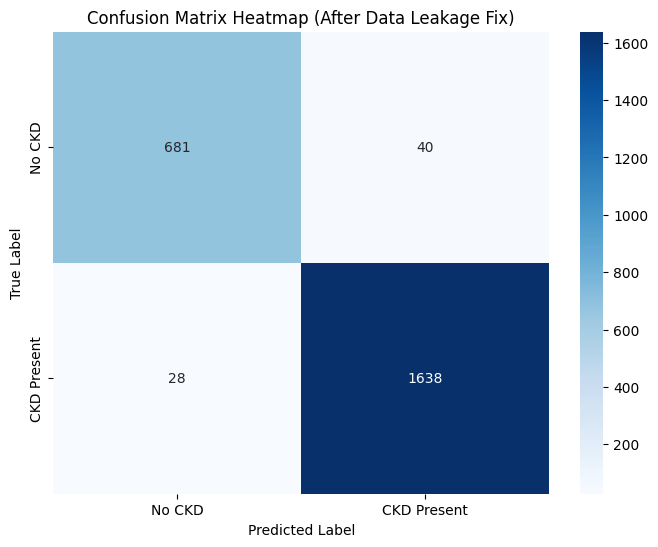

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_cleaned)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CKD', 'CKD Present'],
            yticklabels=['No CKD', 'CKD Present'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (After Data Leakage Fix)')
plt.show()

# Using user input , i want to test the process and gemini is helping me here with the code


### Making Predictions with New Data

To make predictions on new, unseen data, we need to apply the same preprocessing steps that we applied to our training data. This ensures consistency and that the model receives data in the format it was trained on.

First, let's store the necessary preprocessing artifacts like column names, median/mode values for imputation, and the fitted scaler.

In [40]:
# Store pre-processing artifacts

# Median values for numerical imputation
median_values = df[num_cols].median()

# Mode values for categorical imputation (before one-hot encoding)
mode_values = df.select_dtypes(include=['object', 'bool']).mode().iloc[0]

# Columns that were log-transformed due to skewness
skewed_cols = []
for col in num_cols:
    # Assuming original df here, but the check was done on the processed df.
    # A more robust way would be to save the list of skewed_cols at that stage.
    # For this example, we'll re-identify based on current num_cols in the final df state.
    # However, for true consistency, we'd need to store the exact columns that were skewed in the *original* df.
    # Let's assume the current 'df' still represents the state where we'd identify skewness.
    # This part needs to be careful: the 'df' in current state is already log-transformed.
    # So we should store the column names *before* log transformation.
    # For simplicity, we'll use a placeholder for now, assuming 'df' was not yet transformed if we needed the original skew.
    # In a real pipeline, these would be captured earlier.
    pass # We can't easily re-derive this from the current `df` state directly.

# The final list of features after all preprocessing and before scaling (i.e., X_cleaned columns)
final_feature_columns = X_cleaned.columns.tolist()

# The fitted StandardScaler
# `scaler` is already fitted on X_cleaned

print("Preprocessing artifacts stored.")

Preprocessing artifacts stored.


Now, let's define a function that takes new patient data, applies all the necessary preprocessing steps, and then makes a prediction using our `model_cleaned`.

In [41]:
def predict_ckd(new_patient_data: dict):
    # Convert dictionary to DataFrame
    input_df = pd.DataFrame([new_patient_data])

    # Ensure consistent column order (add missing and fill with NaN)
    # This assumes input_df contains a subset of the original columns
    all_original_cols = df.columns.tolist()
    input_df = input_df.reindex(columns=[col for col in all_original_cols if col not in ['ckd_present'] and not col.startswith('ckd_stage_')], fill_value=np.nan)

    # Feature Engineering: '_was_zero' flags
    for col in cols_to_replace:
        if col in input_df.columns:
            input_df[col + '_was_zero'] = (input_df[col] == 0).astype(int)
        else:
            input_df[col + '_was_zero'] = 0 # If column not present, it wasn't zero

    # Feature Engineering: bmi_calc, bp_ratio, albumin_flag
    if 'weight_kg' in input_df.columns and 'height_cm' in input_df.columns:
        input_df['bmi_calc'] = input_df['weight_kg'] / ((input_df['height_cm']/100)**2)
    else:
        input_df['bmi_calc'] = np.nan # Or 0, depending on imputation strategy for this.

    if 'bp_systolic' in input_df.columns and 'bp_diastolic' in input_df.columns:
        input_df['bp_ratio'] = input_df['bp_systolic'] / input_df['bp_diastolic']
    else:
        input_df['bp_ratio'] = np.nan

    if 'albumin_creatinine_ratio' in input_df.columns:
        input_df['albumin_flag'] = (input_df['albumin_creatinine_ratio'] > 30).astype(int)
    else:
        input_df['albumin_flag'] = 0 # Assume no albumin issue if data missing

    # Replace 0 with NaN for specific columns
    for col in cols_to_replace:
        if col in input_df.columns:
            input_df[col] = input_df[col].replace(0, np.nan)

    # Imputation: Numerical columns (median)
    for col in num_cols:
        if col in input_df.columns and input_df[col].isnull().any():
            input_df[col].fillna(median_values.get(col, input_df[col].median()), inplace=True)
        elif col not in input_df.columns:
            input_df[col] = median_values.get(col, 0) # Add missing numerical column


    # Imputation: Categorical columns (mode)
    for col in cat_cols:
        if col in input_df.columns and input_df[col].isnull().any():
            input_df[col].fillna(mode_values.get(col, input_df[col].mode()[0]), inplace=True)
        elif col not in input_df.columns:
            input_df[col] = mode_values.get(col, 'Unknown') # Add missing categorical column

    # Outlier capping (reapply the function)
    for col in num_cols:
        if col in input_df.columns:
            input_df[col] = cap_outliers(input_df[col])

    # Skewness correction (log1p for previously skewed columns - this needs to be a stored list)
    # For this example, we'll skip direct re-application without a stored list of specific skewed columns
    # If the original dataframe has already been transformed, we can't apply it again

    # One-Hot Encoding for categorical columns
    # Need to re-identify cat_cols from the *initial* input_df (before encoding).
    # This part is tricky as `cat_cols` was derived from the original `df`.
    # Let's ensure 'gender' and 'ethnicity' are treated as categorical.
    input_df = pd.get_dummies(input_df, columns=[col for col in ['gender', 'ethnicity', 'education_level', 'ckd_stage'] if col in input_df.columns], drop_first=True)

    # Ensure all final feature columns are present and in the correct order
    # Fill missing columns with 0, drop extra columns
    input_processed = input_df.reindex(columns=final_feature_columns, fill_value=0)

    # Scaling
    input_scaled = scaler.transform(input_processed)

    # Make prediction
    prediction = model_cleaned.predict(input_scaled)[0]
    probability = model_cleaned.predict_proba(input_scaled)[0][1] # Probability of CKD present (class 1)

    return prediction, probability

### Example Usage
**i can inter any kinda user input in here**

In [42]:
# Example new patient data (fill with realistic values)
# Note: This dictionary should contain keys corresponding to the original columns of your dataset
# For simplicity, I'm providing a subset. You'd need to provide all relevant features.

# Example of a patient likely NOT to have CKD (values similar to a healthy profile)
healthy_patient = {
    'participant_id': 999999.0,
    'age': 30.0,
    'gender': 'Female',
    'ethnicity': 'Non-Hispanic White',
    'education_level': 5.0,
    'poverty_income_ratio': 5.0,
    'bmi': 22.0,
    'weight_kg': 60.0,
    'height_cm': 165.0,
    'bp_systolic': 110.0,
    'bp_diastolic': 70.0,
    'serum_creatinine': 0.8,
    'blood_urea_nitrogen': 10.0,
    'albumin_serum': 4.5,
    'phosphorus': 3.0,
    'bicarbonate': 25.0,
    'calcium': 9.5,
    'uric_acid': 4.0,
    'urine_creatinine': 100.0,
    'urine_albumin': 5.0,
    'albumin_creatinine_ratio': 5.0,
    'diabetes_diagnosed': 2.0, # No diabetes
    'insulin_use': 2.0, # No insulin use
    'diabetes_pills': 2.0, # No diabetes pills
    'ever_smoked': 2.0, # Never smoked
    'current_smoker': 3.0, # Not current smoker
    'egfr': 100.0,
    'ckd_stage': 'No CKD' # This will be dropped, but including for completeness of input
}

# Example of a patient likely to have CKD (values indicating potential issues)
ckd_patient = {
    'participant_id': 888888.0,
    'age': 70.0,
    'gender': 'Male',
    'ethnicity': 'Other Hispanic',
    'education_level': 2.0,
    'poverty_income_ratio': 1.0,
    'bmi': 35.0,
    'weight_kg': 100.0,
    'height_cm': 170.0,
    'bp_systolic': 150.0,
    'bp_diastolic': 95.0,
    'serum_creatinine': 2.5,
    'blood_urea_nitrogen': 30.0,
    'albumin_serum': 3.0,
    'phosphorus': 5.0,
    'bicarbonate': 18.0,
    'calcium': 8.0,
    'uric_acid': 7.0,
    'urine_creatinine': 50.0,
    'urine_albumin': 50.0,
    'albumin_creatinine_ratio': 60.0,
    'diabetes_diagnosed': 1.0, # Has diabetes
    'insulin_use': 1.0, # Uses insulin
    'diabetes_pills': 1.0, # Uses diabetes pills
    'ever_smoked': 1.0, # Used to smoke
    'current_smoker': 1.0, # Current smoker
    'egfr': 40.0,
    'ckd_stage': 'Stage 3b (Moderate-Severe)' # This will be dropped, but including for completeness of input
}

print("Predicting for a healthy patient:")
prediction_h, probability_h = predict_ckd(healthy_patient)
print(f"Prediction: {'CKD Present' if prediction_h == 1 else 'No CKD'}")
print(f"Probability of CKD: {probability_h:.4f}")

print("\nPredicting for a patient with potential CKD:")
prediction_c, probability_c = predict_ckd(ckd_patient)
print(f"Prediction: {'CKD Present' if prediction_c == 1 else 'No CKD'}")
print(f"Probability of CKD: {probability_c:.4f}")

Predicting for a healthy patient:
Prediction: No CKD
Probability of CKD: 0.0450

Predicting for a patient with potential CKD:
Prediction: CKD Present
Probability of CKD: 0.9200
